# Task 1: Foundational Setup & Exploratory Data Analysis (EDA)

**ApexPlanet Software Pvt. Ltd. — Data Analytics Internship**
**Dataset:** E-commerce Sales (synthetic, 2023–2024, India-focused)

**Objective:** Set up the environment, clean the raw e-commerce sales data,
and perform exploratory data analysis to surface initial business insights.


## 1. Environment Setup & Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix path so it works from any location
os.chdir(os.path.dirname(os.path.abspath("__file__")))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)

print("✅ Libraries loaded successfully!")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

✅ Libraries loaded successfully!
pandas: 2.3.3
numpy: 2.3.3


## 2. Load Raw Dataset

In [2]:
df = pd.read_csv("../data/ecommerce_sales_raw.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (6090, 18)

First 5 rows:


,Order_ID,Order_Date,Customer_ID,Customer_Segment,Region,City,Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Gross_Sales,Discount_Amount,Net_Sales,Profit,Payment_Method,Ship_Mode,Customer_Rating
0,ORD-002565,2024-12-01,CUST-00737,Consumer,North,Chandigarh,Electronics,Laptop Stand,2,883.45,0.0,1766.90,0.00,1766.90,384.27,UPI,Standard,5.0
1,ORD-004275,2024-06-04,CUST-00601,Consumer,East,Bhubaneswar,Electronics,Wireless Earbuds,5,4111.50,10.0,20557.50,2055.75,18501.75,6462.08,Credit Card,Express,5.0
2,ORD-003045,2024-10-10,CUST-00665,Consumer,South,Chennai,Fashion,Leather Wallet,5,502.49,10.0,2512.45,251.25,2261.20,266.12,Credit Card,Standard,5.0
3,ORD-005168,2024-01-19,CUST-00214,Small Business,South,Chennai,Beauty & Personal Care,Lipstick Set,1,680.07,5.0,680.07,34.00,646.07,59.03,Cash on Delivery,Standard,NaN
4,ORD-003986,2023-09-22,CUST-01268,Premium,South,Kochi,Beauty & Personal Care,Perfume,1,658.19,0.0,658.19,0.00,658.19,160.71,Credit Card,Standard,3.0


In [3]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6090 entries, 0 to 6089
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          6090 non-null   object 
 1   Order_Date        6090 non-null   object 
 2   Customer_ID       6090 non-null   object 
 3   Customer_Segment  6090 non-null   object 
 4   Region            6090 non-null   object 
 5   City              6000 non-null   object 
 6   Category          6090 non-null   object 
 7   Product_Name      6090 non-null   object 
 8   Quantity          6090 non-null   int64  
 9   Unit_Price        6060 non-null   float64
 10  Discount_Percent  5969 non-null   float64
 11  Gross_Sales       6090 non-null   float64
 12  Discount_Amount   6090 non-null   float64
 13  Net_Sales         6090 non-null   float64
 14  Profit            6090 non-null   float64
 15  Payment_Method    6090 non-null   object 
 16  Ship_Mode         6030 non-n

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Order_ID               0
Order_Date             0
Customer_ID            0
Customer_Segment       0
Region                 0
City                  90
Category               0
Product_Name           0
Quantity               0
Unit_Price            30
Discount_Percent     121
Gross_Sales            0
Discount_Amount        0
Net_Sales              0
Profit                 0
Payment_Method         0
Ship_Mode             60
Customer_Rating     1558
dtype: int64

Duplicate rows: 89


## 3. Data Cleaning

In [5]:
# Step 1: Standardize Category text
df["Category"] = df["Category"].str.strip().str.title()

# Step 2: Parse dates
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# Step 3: Remove duplicates
dupes_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"✅ Removed {dupes_before} duplicate rows")
print(f"Shape after dedup: {df.shape}")

✅ Removed 89 duplicate rows
Shape after dedup: (6001, 18)


In [6]:
# Step 4: Handle missing values
df["City"] = df["City"].fillna("Unknown")
df["Ship_Mode"] = df["Ship_Mode"].fillna(df["Ship_Mode"].mode()[0])
df["Unit_Price"] = df["Unit_Price"].fillna(df.groupby("Category")["Unit_Price"].transform("median"))
df["Discount_Percent"] = df["Discount_Percent"].fillna(0)
df["Has_Rating"] = df["Customer_Rating"].notna().astype(int)
df["Customer_Rating"] = df["Customer_Rating"].fillna(0)

print("✅ Missing values handled!")
print("Remaining missing values:", df.isna().sum().sum())

✅ Missing values handled!
Remaining missing values: 0


In [7]:
# Step 5: Fix data types
for col in ["Customer_Segment", "Region", "Category", "Payment_Method", "Ship_Mode"]:
    df[col] = df[col].astype("category")

print("✅ Data types fixed!")
print(df.dtypes)

✅ Data types fixed!
Order_ID                    object
Order_Date          datetime64[ns]
Customer_ID                 object
Customer_Segment          category
Region                    category
City                        object
Category                  category
Product_Name                object
Quantity                     int64
Unit_Price                 float64
Discount_Percent           float64
Gross_Sales                float64
Discount_Amount            float64
Net_Sales                  float64
Profit                     float64
Payment_Method            category
Ship_Mode                 category
Customer_Rating            float64
Has_Rating                   int64
dtype: object


In [8]:
# Step 6: Outlier detection using IQR method
Q1 = df["Net_Sales"].quantile(0.25)
Q3 = df["Net_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df["Net_Sales"] < lower_bound) | (df["Net_Sales"] > upper_bound)
n_outliers = outliers_mask.sum()

df["Net_Sales_Capped"] = df["Net_Sales"].clip(lower=lower_bound, upper=upper_bound)

print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers detected and capped: {n_outliers}")

IQR bounds: [-8012.25, 18638.31]
Outliers detected and capped: 247


In [9]:
# Add time columns and save
df["Order_Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Weekday"] = df["Order_Date"].dt.day_name()

df.to_csv("../data/ecommerce_sales_cleaned.csv", index=False)
print(f"✅ Cleaned dataset saved!")
print(f"Final shape: {df.shape}")

✅ Cleaned dataset saved!
Final shape: (6001, 23)


## 4. Exploratory Data Analysis (EDA)

In [10]:
# Statistical summary
print("Statistical Summary:")
df[["Quantity", "Unit_Price", "Discount_Percent", "Net_Sales", "Profit"]].describe()

Statistical Summary:


,Quantity,Unit_Price,Discount_Percent,Net_Sales,Profit
count,6001.000000,6001.000000,6001.000000,6001.000000,6001.00000
mean,3.215797,2141.826821,5.808199,6440.154249,1309.68903
std,5.298420,1450.633143,7.248336,12897.308848,1312.89618
min,1.000000,52.590000,0.000000,54.570000,6.38000
25%,2.000000,882.380000,0.000000,1981.710000,375.74000
50%,3.000000,1849.470000,0.000000,4356.030000,868.45000
75%,4.000000,3182.840000,10.000000,8644.350000,1805.69000
max,180.000000,5999.910000,25.000000,682874.550000,8172.77000


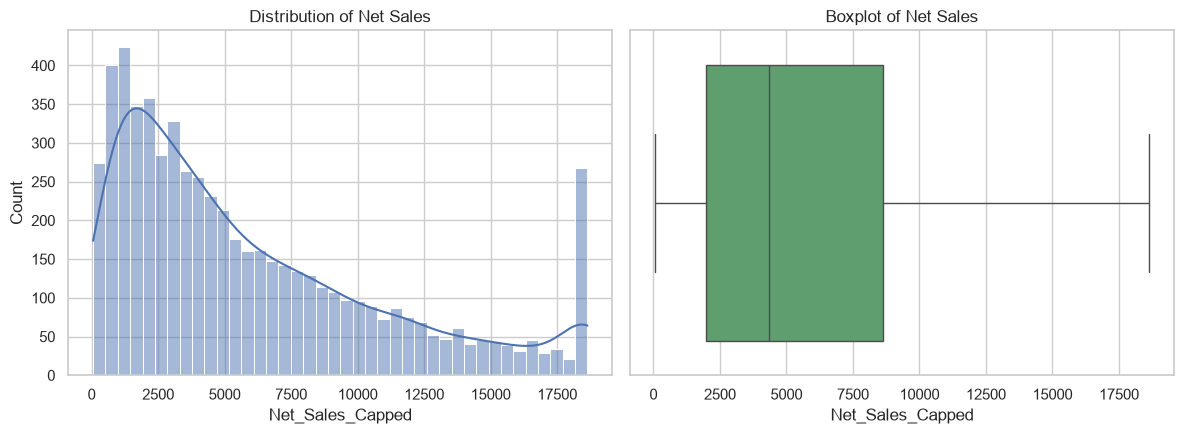

✅ Chart 1 done!


In [11]:
# Chart 1: Distribution of Net Sales
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Net_Sales_Capped"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Net Sales")
sns.boxplot(x=df["Net_Sales_Capped"], ax=axes[1], color="#55A868")
axes[1].set_title("Boxplot of Net Sales")
plt.tight_layout()
plt.show()
print("✅ Chart 1 done!")

C:\Users\HP\AppData\Local\Temp\ipykernel_31348\1529006155.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_sales = df.groupby("Category")["Net_Sales"].sum().sort_values(ascending=False)


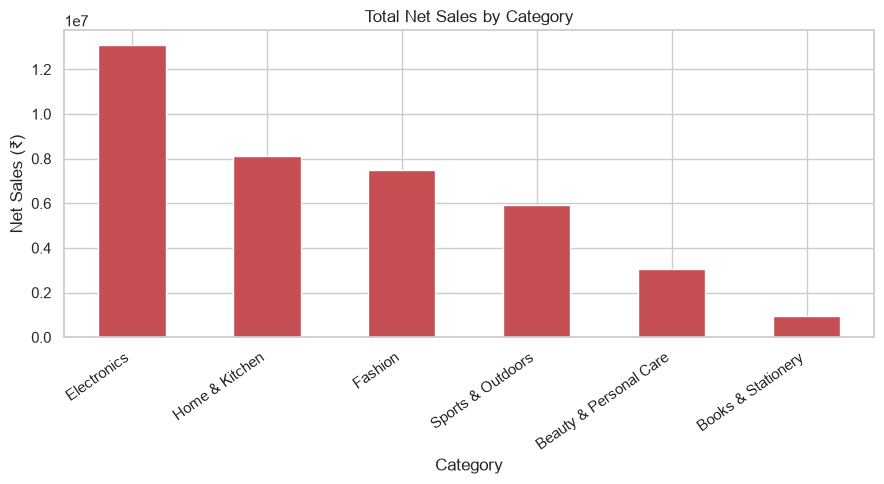

✅ Chart 2 done!


In [12]:
# Chart 2: Sales by Category
fig, ax = plt.subplots(figsize=(9, 5))
cat_sales = df.groupby("Category")["Net_Sales"].sum().sort_values(ascending=False)
cat_sales.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Total Net Sales by Category")
ax.set_ylabel("Net Sales (₹)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()
print("✅ Chart 2 done!")

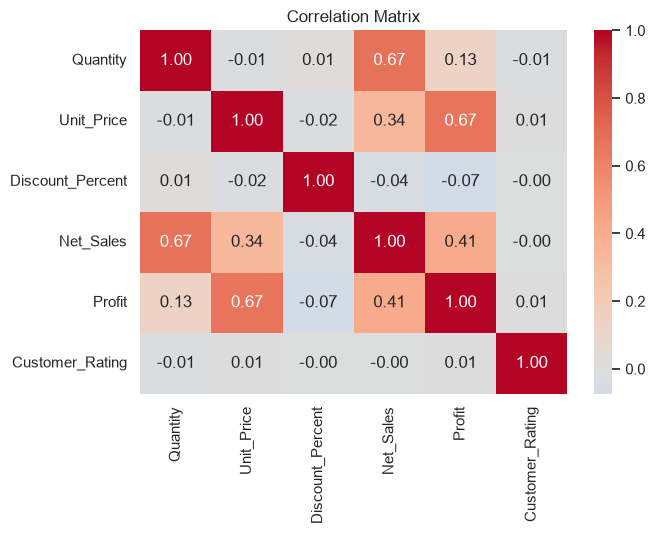

✅ Chart 3 done!


In [13]:
# Chart 3: Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5.5))
corr_cols = ["Quantity", "Unit_Price", "Discount_Percent", "Net_Sales", "Profit", "Customer_Rating"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()
print("✅ Chart 3 done!")

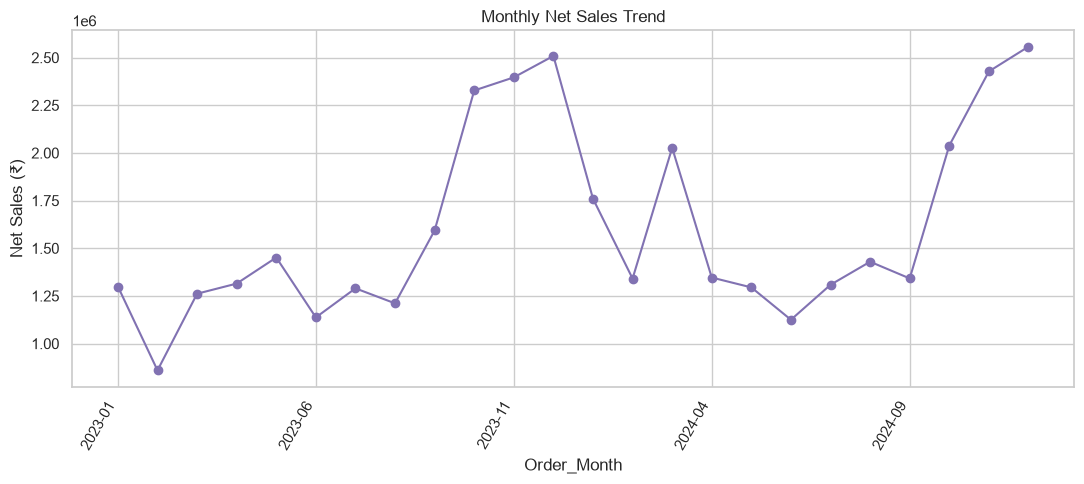

✅ Chart 4 done!


In [14]:
# Chart 4: Monthly Sales Trend
fig, ax = plt.subplots(figsize=(11, 5))
monthly = df.groupby("Order_Month")["Net_Sales"].sum().sort_index()
monthly.plot(ax=ax, marker="o", color="#8172B2")
ax.set_title("Monthly Net Sales Trend")
ax.set_ylabel("Net Sales (₹)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()
print("✅ Chart 4 done!")

C:\Users\HP\AppData\Local\Temp\ipykernel_31348\1238616126.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_sales = df.groupby("Region")["Net_Sales"].sum().sort_values(ascending=False)


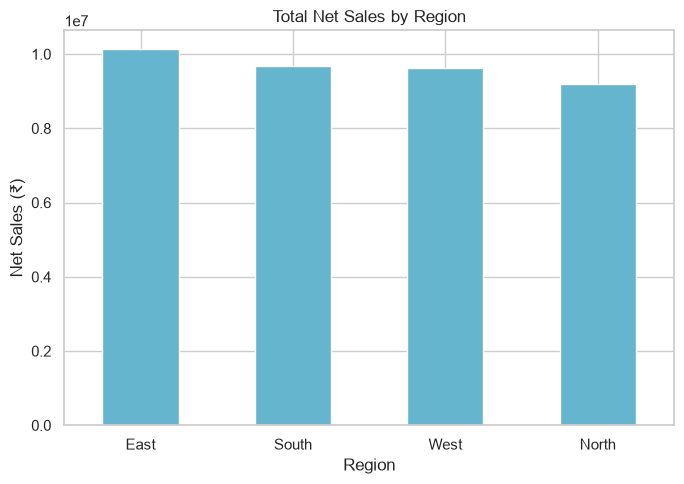

✅ Chart 5 done!


In [15]:
# Chart 5: Sales by Region
fig, ax = plt.subplots(figsize=(7, 5))
region_sales = df.groupby("Region")["Net_Sales"].sum().sort_values(ascending=False)
region_sales.plot(kind="bar", ax=ax, color="#64B5CD")
ax.set_title("Total Net Sales by Region")
ax.set_ylabel("Net Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("✅ Chart 5 done!")

## 5. Key Insights

In [16]:
top_category = cat_sales.idxmax()
top_category_pct = cat_sales.max() / cat_sales.sum() * 100
top_region = region_sales.idxmax()
best_month = monthly.idxmax()
avg_discount = df["Discount_Percent"].mean()

print("=" * 60)
print("KEY INSIGHTS — E-commerce Sales Analysis")
print("=" * 60)
print(f"\n1. Top Category: '{top_category}' contributes {top_category_pct:.1f}% of total sales")
print(f"\n2. Top Region: '{top_region}' generates ₹{region_sales.max():,.0f} in sales")
print(f"\n3. Best Month: {best_month} had ₹{monthly.max():,.0f} in sales (festive season)")
print(f"\n4. Avg Discount: {avg_discount:.1f}% across all orders")
print(f"\n5. Outliers: {n_outliers} bulk/wholesale orders capped using IQR method")
print(f"\n✅ Task 1 Complete!")

KEY INSIGHTS — E-commerce Sales Analysis

1. Top Category: 'Electronics' contributes 33.9% of total sales

2. Top Region: 'East' generates ₹10,130,655 in sales

3. Best Month: 2024-12 had ₹2,557,496 in sales (festive season)

4. Avg Discount: 5.8% across all orders

5. Outliers: 247 bulk/wholesale orders capped using IQR method

✅ Task 1 Complete!
